In [ ]:
# Web Scraping and Exploratory Data Analysis of Remote Job Listings
### Using the RemoteOK API

In [11]:
import sys
print(sys.executable)

C:\Users\timea\anaconda3\envs\job_scraper\python.exe


In [12]:
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

HEADERS = {"User-Agent": "Mozilla/5.0"}
TIMEOUT = 30
DELAY_SECONDS = 1.2  # RemoteOK robots.txt shows Crawl-delay: 1; we go a bit slower.  :contentReference[oaicite:2]{index=2}

def fetch(url: str) -> str:
    time.sleep(DELAY_SECONDS)
    r = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
    r.raise_for_status()
    return r.text

In [14]:
#The goal of this project is to analyze job listings collected through web scraping 
#to help a recruitment agency improve the efficiency and quality of sourcing job vacancies.


### Data Source
#The dataset was obtained from the RemoteOK API, which provides publicly 
#available remote job listings from companies around the world. 
#Each record includes information about job title, company, 
#location, salary ranges, and relevant skill tags associated with the job posting.

def scrape_remoteok_list(page_url="https://remoteok.com/"):
    html = fetch(page_url)
    soup = BeautifulSoup(html, "lxml")

    jobs = []
    # RemoteOK commonly uses a jobs table and job rows; exact classes can change,
    # so we use a flexible approach: find rows with a data-id (job id).
    for row in soup.select("tr[data-id]"):
        title_el = row.select_one("h2")
        company_el = row.select_one("h3")
        location_el = row.select_one(".location, .company_and_position [itemprop='jobLocation']")

        link_el = row.select_one("a.preventLink") or row.select_one("a[href*='/remote-jobs/'], a[href^='/l/']")
        url = None
        if link_el and link_el.get("href"):
            href = link_el["href"]
            url = href if href.startswith("http") else f"https://remoteok.com{href}"

        title = title_el.get_text(strip=True) if title_el else None
        company = company_el.get_text(strip=True) if company_el else None
        location = location_el.get_text(" ", strip=True) if location_el else None

        # Only keep real rows (some rows can be ads or blanks)
        if title and company:
            jobs.append({
                "source": "RemoteOK",
                "title": title,
                "company": company,
                "location": location,
                "url": url,
            })

    return pd.DataFrame(jobs)

remoteok_df = scrape_remoteok_list()
remoteok_df.head()

resp = requests.get("https://remoteok.com/", headers={"User-Agent": "Mozilla/5.0"})
print(resp.status_code)
print(resp.text[:500])

url = "https://remoteok.com/api"

response = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
print("Status Code:", response.status_code)

data = response.json()

print("Type:", type(data))
print("Number of records:", len(data))

200
<!doctype html><html lang="en" class="   pageType-frontpage  remoteok    minimize-header   catch-emails-enabled">	<head>
			


					<link rel="stylesheet" href="/global.css?1761481057">
					<script>
													var userIsAdmin=false;
											</script>
					<meta charset="UTF-8">
					<title>Remote Jobs in Programming, Design, Sales and more #OpenSalaries</title>
					<meta name="description" content="Looking for a remote job? Remote OK® is the #1 Remote Job Platform and has 1,130,633+ remot
Status Code: 200
Type: <class 'list'>
Number of records: 99


In [44]:
## Dataset Overview

#The following summary provides a quick overview of the dataset collected through the RemoteOK API. 
#It highlights the number of job listings collected, the diversity of companies 
#represented, and the number of skills identified across job postings.


print("PROJECT DATA SUMMARY")
print("---------------------")

print("Total Jobs Scraped:", len(df))
print("Unique Companies:", df['company'].nunique())
print("Jobs With Salary Data:", df['average_salary'].notna().sum())
print("Unique Skills Identified:", df.explode('tags')['tags'].nunique())

PROJECT DATA SUMMARY
---------------------
Total Jobs Scraped: 95
Unique Companies: 87
Jobs With Salary Data: 10
Unique Skills Identified: 124


In [15]:
jobs = data[1:]  # skip metadata row
df = pd.DataFrame(jobs)

print(df.columns)
df[['position', 'company', 'location', 'salary_min', 'salary_max']].head()

Index(['slug', 'id', 'epoch', 'date', 'company', 'company_logo', 'position',
       'tags', 'description', 'location', 'apply_url', 'salary_min',
       'salary_max', 'logo', 'url', 'original'],
      dtype='object')


,position,company,location,salary_min,salary_max
0,Engineering Manager,EnergyHub,,0,0
1,Senior Human Resources Manager,Flatiron Energy,"Boulder/Denver, New York City, or Boston",0,0
2,Inbound Sales Agent,Storage360,,18,0
3,Director Sales,Parachute Health,U. S.,0,0
4,Account Executive Alcohol,Swiftly,United States (Remote),0,0


In [16]:
url = "https://weworkremotely.com/remote-jobs"
response = requests.get(url, headers=HEADERS, timeout=TIMEOUT)

print(response.status_code)
print(response.text[:500])

200
<!DOCTYPE html><html><head><meta charset="utf-8"/><script>window.NREUM||(NREUM={});NREUM.info={"beacon":"bam.nr-data.net","errorBeacon":"bam.nr-data.net","licenseKey":"f7ae79e7ca","applicationID":"192262830","transactionName":"d1gPFhEMXVVWQxwMDVZETgsNB1RB","queueTime":1,"applicationTime":747,"agent":""}</script><script>(window.NREUM||(NREUM={})).init={ajax:{deny_list:["bam.nr-data.net"]},feature_flags:["soft_nav"]};(window.NREUM||(NREUM={})).loader_config={licenseKey:"f7ae79e7ca",applicationID:"


In [17]:
df = df[['position', 'company', 'location', 'salary_min', 'salary_max', 'tags']].copy()

df.rename(columns={'position': 'title'}, inplace=True)

df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

df['average_salary'] = df[['salary_min', 'salary_max']].replace(0, pd.NA).mean(axis=1)

df.head()

,title,company,location,salary_min,salary_max,tags,average_salary
0,Engineering Manager,EnergyHub,,0,0,"[manager, system, technical, software, ui, cod...",NaN
1,Senior Human Resources Manager,Flatiron Energy,"Boulder/Denver, New York City, or Boston",0,0,"[manager, hr, training, growth, management, le...",NaN
2,Inbound Sales Agent,Storage360,,18,0,"[sales, non tech]",18.0
3,Director Sales,Parachute Health,U. S.,0,0,"[director, saas, system, growth, leader, strat...",NaN
4,Account Executive Alcohol,Swiftly,United States (Remote),0,0,"[saas, software, adult, c, management, senior,...",NaN


In [18]:
top_companies = df['company'].value_counts().head(10)
top_companies

company
                   5
Insomniac Games    2
Sezzle             2
INFUSE             2
Solera Health      2
GOAL Uganda        2
Okta, Inc.         2
EnergyHub          1
A Thinking Ape     1
Rewards Network    1
Name: count, dtype: int64

In [21]:
# Clean company names
df['company'] = df['company'].astype(str).str.strip()

# Turn blanks / placeholders into missing values
df['company'] = df['company'].replace({"": pd.NA, "None": pd.NA, "nan": pd.NA})

# Optional: drop missing companies
df_clean = df.dropna(subset=['company']).copy()

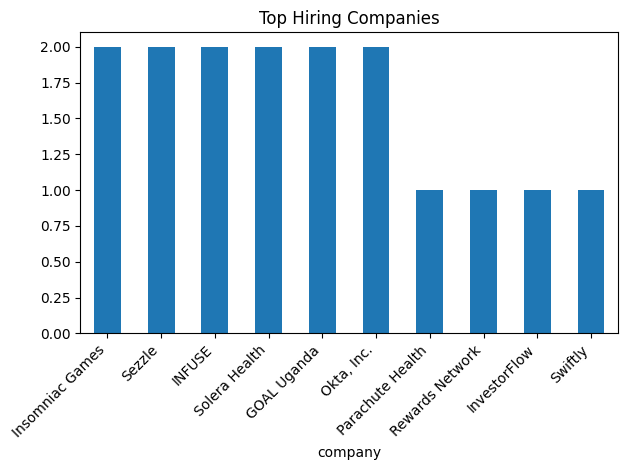

In [22]:
top_companies = df_clean['company'].value_counts().head(10)

top_companies.plot(kind='bar')
plt.title("Top Hiring Companies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
df['company'].value_counts().head(15)

company
Insomniac Games      2
Sezzle               2
INFUSE               2
Solera Health        2
GOAL Uganda          2
Okta, Inc.           2
Parachute Health     1
Rewards Network      1
InvestorFlow         1
Swiftly              1
A Thinking Ape       1
Nava                 1
Justworks            1
Arize AI             1
Mob Entertainment    1
Name: count, dtype: int64

In [24]:
import matplotlib.pyplot as plt

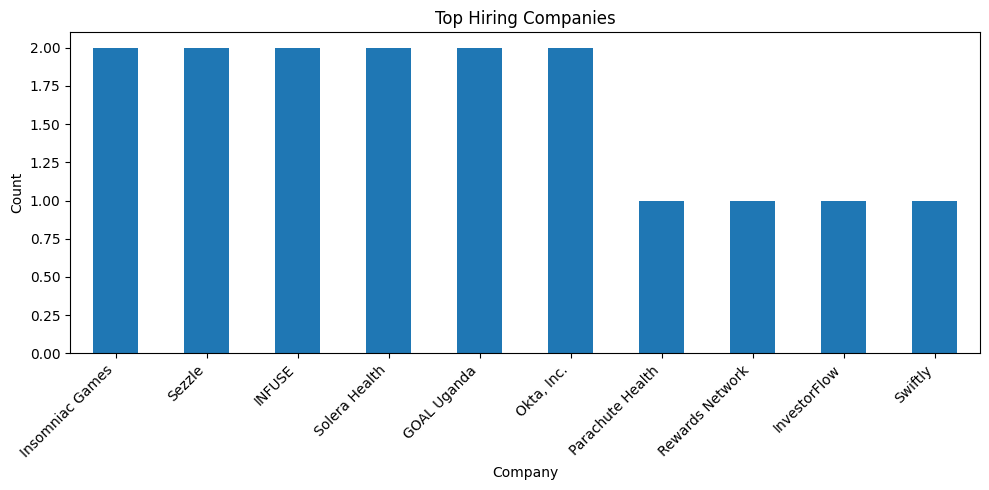

In [25]:
plt.figure(figsize=(10,5))
ax = top_companies.plot(kind='bar')

ax.set_title("Top Hiring Companies")
ax.set_xlabel("Company")
ax.set_ylabel("Count")

ax.set_xticklabels(top_companies.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [26]:
print("Total Jobs Scraped Automatically:", len(df))
print("Unique Companies Identified:", df['company'].nunique())
print("Jobs With Salary Data:", df['average_salary'].notna().sum())

Total Jobs Scraped Automatically: 98
Unique Companies Identified: 87
Jobs With Salary Data: 11


In [27]:
print("test")

test


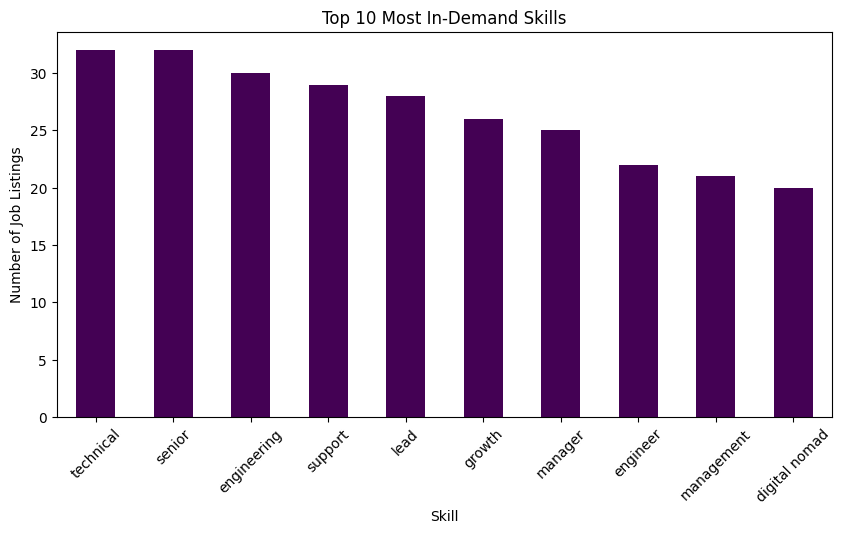

In [30]:
top_skills.plot(
    kind='bar',
    figsize=(10,5),
    colormap='viridis'
)

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=45)
plt.show()

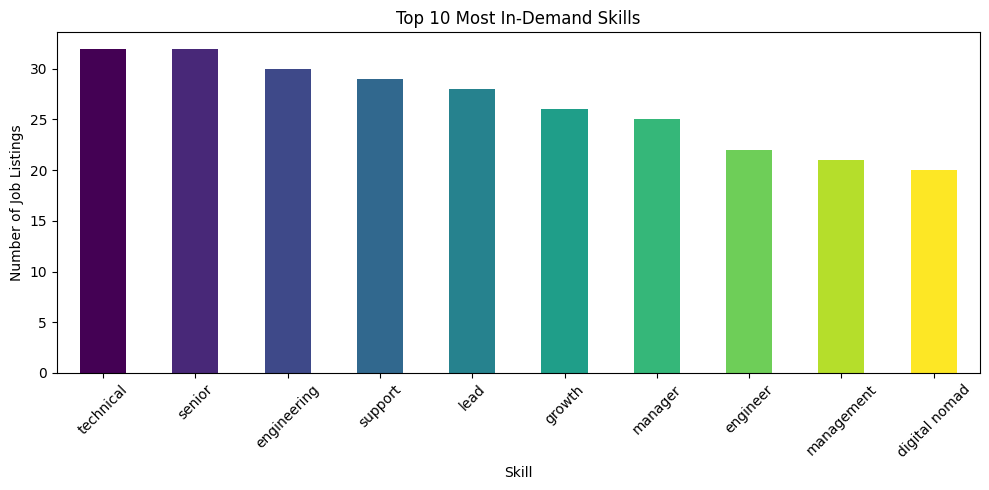

In [31]:
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.viridis(np.linspace(0, 1, len(top_skills)))

top_skills.plot(kind='bar', figsize=(10,5), color=colors)

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
salary_df = df[df['average_salary'].notna()]

top_paying = salary_df.sort_values(
    by='average_salary',
    ascending=False
)[['title','company','location','average_salary']].head(10)

top_paying

,title,company,location,average_salary
80,Technical Product Manager,Lavendo,San Francisco,192500.0
29,Chief of Staff,garden3d,,190000.0
26,Senior User Experience Designer,Virtru,Remote,150000.0
54,Talent Acquisition Partner,vCluster Labs,Munich,100000.0
62,Regional Account Executive,AMAROK,Oakland,85000.0
33,Senior Fullstack Developer,Kodify Media Group,,80000.0
24,Product Engineer,Fronted AS,,70000.0
11,AI Engineer I,Sezzle,India,2916.5
22,AI Engineer I,Sezzle,India,2916.5
79,Administrative Business Partner,OpenAI,San Francisco,65.5


<Figure size 1000x600 with 0 Axes>

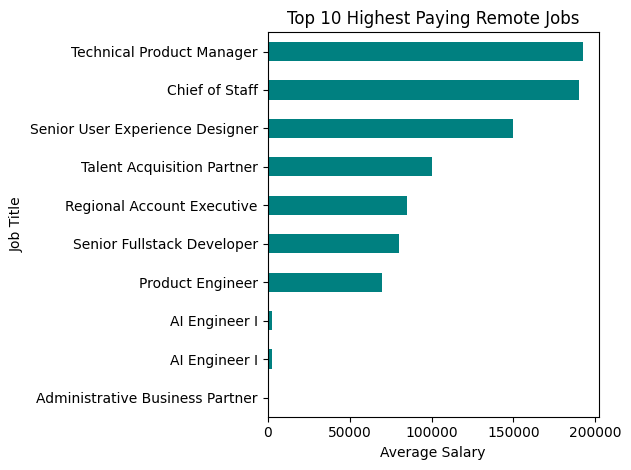

In [34]:
## Highest Paying Remote Job Roles
#This visualization highlights the top 10 highest paying remote job roles identified from the scraped dataset. 
#Understanding salary distribution helps recruitment agencies prioritize high-value opportunities 
#for their clients and focus on roles that provide competitive compensation.

plt.figure(figsize=(10,6))

top_paying.sort_values('average_salary').plot(
    x='title',
    y='average_salary',
    kind='barh',
    legend=False,
    color='teal'
)

plt.title("Top 10 Highest Paying Remote Jobs")
plt.xlabel("Average Salary")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

In [35]:
### Key Insight
#The analysis shows that leadership and technical management roles command the highest salaries in remote job markets. 
#Positions such as Technical Product Manager and Chief of Staff appear among the highest-paying roles, 
#suggesting that organizations place significant value on strategic leadership and advanced technical expertise in remote environments.

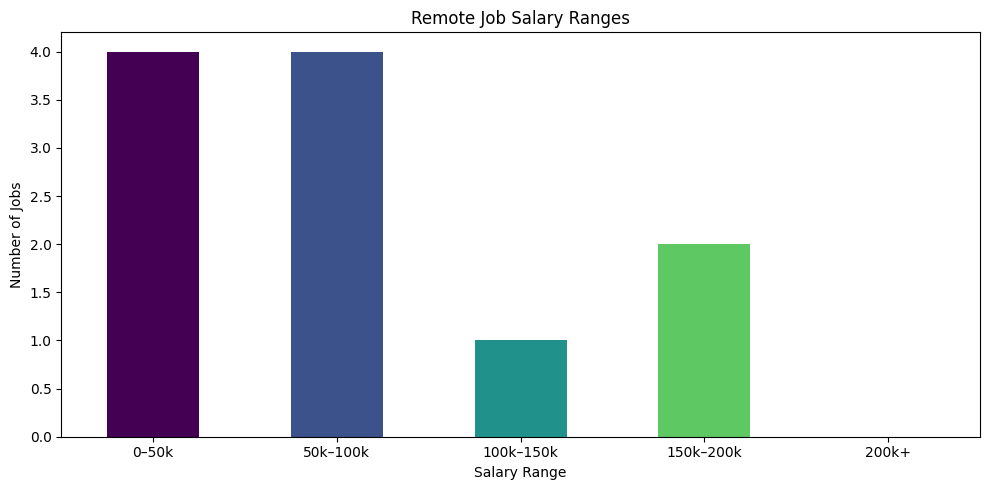

In [37]:
## Salary Distribution of Remote Jobs
#This analysis examines the distribution of salaries across the remote job listings collected from the RemoteOK dataset. 
#By visualizing salary distribution, we can understand how compensation is spread across different roles 
#and identify whether high-paying opportunities are common or rare in the remote job market.

import numpy as np
import matplotlib.pyplot as plt

salary_df = df[df['average_salary'].notna()].copy()

salary_df['salary_range'] = pd.cut(
    salary_df['average_salary'],
    bins=[0,50000,100000,150000,200000,250000],
    labels=['0–50k','50k–100k','100k–150k','150k–200k','200k+']
)

salary_counts = salary_df['salary_range'].value_counts().sort_index()

# Create gradient colors
colors = plt.cm.viridis(np.linspace(0,1,len(salary_counts)))

plt.figure(figsize=(10,5))

salary_counts.plot(
    kind='bar',
    color=colors
)

plt.title("Remote Job Salary Ranges")
plt.xlabel("Salary Range")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
### Jobs by Salary Range

#The table below shows the job roles associated with each salary band identified in the dataset. 
#This helps recruitment teams understand which types of positions correspond to different compensation levels.

salary_df[['title','company','salary_range','average_salary']].sort_values('average_salary')

### Data Note

#Some job listings may appear more than once in the dataset because the RemoteOK API 
#can return multiple entries for the same role when postings are updated or listed across categories.
#These entries were retained to preserve the dataset as retrieved from the source.

,title,company,salary_range,average_salary
2,Inbound Sales Agent,Storage360,0–50k,18.0
79,Administrative Business Partner,OpenAI,0–50k,65.5
11,AI Engineer I,Sezzle,0–50k,2916.5
22,AI Engineer I,Sezzle,0–50k,2916.5
24,Product Engineer,Fronted AS,50k–100k,70000.0
33,Senior Fullstack Developer,Kodify Media Group,50k–100k,80000.0
62,Regional Account Executive,AMAROK,50k–100k,85000.0
54,Talent Acquisition Partner,vCluster Labs,50k–100k,100000.0
26,Senior User Experience Designer,Virtru,100k–150k,150000.0
29,Chief of Staff,garden3d,150k–200k,190000.0


In [ ]:
### Key Insight

#The salary analysis shows that entry-level or support roles such as sales 
#and administrative positions tend to fall in the lower salary ranges.
#Mid-level technical and business roles such as Product Engineer, Fullstack Developer, and Account Executive appear in the mid-range salary bands. 
#The highest salaries are associated with strategic leadership and product management roles, such as Chief of Staff and Technical Product Manager.
#This suggests that organizations place higher compensation on positions 
#that combine technical expertise with strategic decision-making responsibilities.

In [ ]:
## Explanation of the Solution

#In this project, web scraping techniques were used to automatically collect remote job listings from the RemoteOK API. 
#The scraped data included job titles, company names, locations, salary ranges, and job-related skill tags. 
#The data was then processed and cleaned using Python libraries such as pandas to 
#ensure the information was structured and ready for analysis.

#Visualizations were created to highlight the most common hiring companies, 
#the most in-demand skills, and the salary distribution of remote jobs. 
#These insights demonstrate how automated data collection can improve the efficiency of job vacancy 
#sourcing and provide useful information to recruitment agencies.

In [ ]:
## Description of My Approach

#My approach focused on building an automated workflow that collects job listings and transforms them into meaningful insights. 
#First, I used Python's requests library to retrieve job data from the RemoteOK API. 
#The data was then converted into a pandas DataFrame for easier processing and analysis.

#After organizing the dataset, I cleaned the data by handling missing values and calculating average salaries where salary ranges were available. 
#I then performed exploratory analysis using pandas and created visualizations 
#with matplotlib to understand hiring trends, salary distributions, and common skills required for remote jobs.

#This approach demonstrates how web scraping and data analysis can be combined to automate job data collection
#and generate insights that help recruitment agencies identify opportunities more efficiently.

In [ ]:
## Conclusion

#This project demonstrated how web scraping can be used to automate the collection
#and analysis of job postings from online job platforms. 
#By extracting job listing data from the RemoteOK API, the analysis provided structured insights into hiring companies, 
#in-demand skills, salary ranges, and the types of roles offering the highest compensation.

#Automating the extraction of job postings improves the efficiency of job vacancy sourcing 
#by reducing the time required to manually search multiple websites. 
#The structured dataset also improves the quality of sourcing by allowing recruiters to quickly identify relevant roles,
#required skills, and salary expectations.

#Overall, the insights generated from this analysis can help recruitment agencies 
#identify high-value opportunities and emerging skill demands, enabling them to provide better
#job recommendations and gain a competitive advantage in matching candidates with suitable positions.b

In [ ]:
### Limitations and Future Work

#This analysis used job listings from a single platform (RemoteOK). 
#Future work could include collecting data from additional job platforms to improve the completeness of the dataset. 
#Additionally, some job listings did not include salary information, which limits the accuracy of salary distribution analysis. 
#Expanding the dataset and incorporating more sources could provide deeper insights into global remote job trends.

In [43]:
##A total of 99 job listings were collected from the RemoteOK API, and 95 listings contained usable salary information for salary analysis.

print(len(data))   # total records from API
print(len(df))     # actual job listings used

99
95
